# Preparation for interpolation

In [ ]:
import sys
sys.path.append('../../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Preparation interpolation

search F range 

In [2]:
sigma_rsl = 2000
Sigmas = np.linspace(0.01, 59.4, sigma_rsl)
# Sigmas = np.linspace(0.01, 8, sigma_rsl)
print([np.min(Sigmas), np.max(Sigmas)])

C0s = np.zeros_like(Sigmas)
As = np.zeros_like(Sigmas)
Errors = np.zeros_like(Sigmas)

pbar = tqdm(Sigmas)
for i, sigma in enumerate(pbar):
    pbar.set_description(f"Processing sigma={sigma:.4f}")
    
    C0 = find_C0_sigma(sigma,
                 condition='mean'
                  )
    C0s[i] = C0
    
    if C0==None:
        print(f"Warning: C0 is None for sigma={sigma:.4f}")
        A=None
        Errors[i] = None
    else:
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A
        Errors[i] = np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

[0.01, 59.4]


Processing sigma=59.4000: 100%|██████████| 2000/2000 [15:16<00:00,  2.18it/s]


In [3]:
mask = ~pd.isnull(C0s) & ~pd.isnull(As) & ~pd.isnull(Errors)
C0s = C0s[mask]
As = As[mask]
Errors = Errors[mask]
Sigmas = Sigmas[mask]
print(len(Sigmas), len(C0s), len(As), len(Errors))

2000 2000 2000 2000


In [4]:
# sigma_rsl=5000
# # sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
# sigmas=np.linspace(0.1, 59.0, sigma_rsl)
# print([np.min(sigmas),np.max(sigmas)])
# C0s=np.zeros_like(sigmas)
# As=np.zeros_like(sigmas)
# Vars_sqrt=np.zeros_like(sigmas)
# for i, sigma in enumerate(sigmas):
#     C0=C0_sigma(sigma)
#     C0s[i]=C0
#     A=find_A_sigma(C_0=C0, sigma=sigma)
#     As[i]=A
#     Vars_sqrt[i]=np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

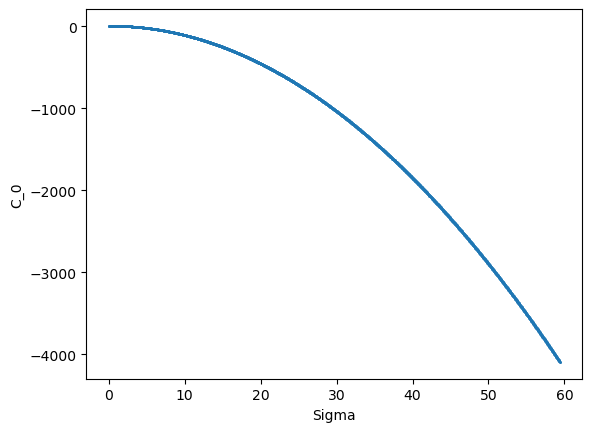

In [5]:
plt.scatter(Sigmas, C0s,  s=1)

plt.ylabel('C_0')
plt.xlabel('Sigma')
# plt.xlim(0,10)

plt.show()

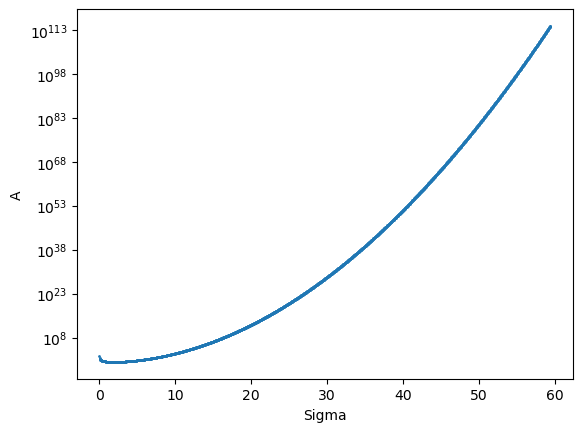

In [6]:
plt.scatter(Sigmas, As,  s=1)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
# plt.xlim(0,10)

plt.show()

Text(0.5, 0, 'Variance_sqrt')

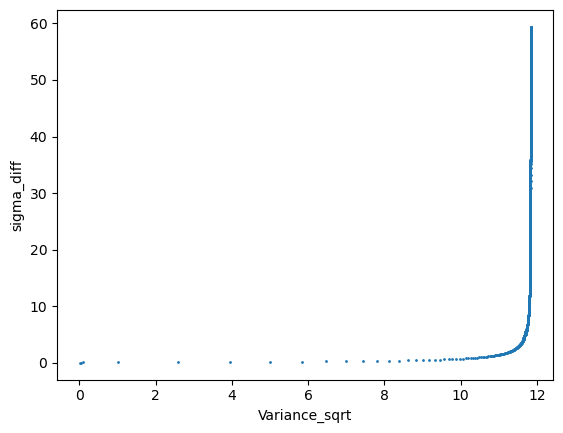

In [7]:
plt.scatter(Errors, Sigmas,s=1)
plt.ylabel('sigma_diff')
plt.xlabel('Variance_sqrt')
# plt.xlim(0.7, 0.8)
# plt.xscale('log')
# plt.yscale('log')

In [8]:
""" def f_var_sigma(sigma_rsl):
    sigmas = np.linspace(0.01, 59.4, sigma_rsl)
    # sigmas = np.linspace(0.01, 8, sigma_rsl)

    C0s = np.zeros_like(sigmas)
    As = np.zeros_like(sigmas)
    Vars_sqrt = np.zeros_like(sigmas)

    pbar = tqdm(sigmas)
    for i, sigma in enumerate(pbar):
        pbar.set_description(f"Processing sigma={sigma:.4f}")
    
        C0 = C0_sigma(sigma,
                 #  condition='median'
                  )
        C0s[i] = C0
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A
        Vars_sqrt[i] = np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))
        
    return sigmas, Vars_sqrt, C0s, As """

' def f_var_sigma(sigma_rsl):\n    sigmas = np.linspace(0.01, 59.4, sigma_rsl)\n    # sigmas = np.linspace(0.01, 8, sigma_rsl)\n\n    C0s = np.zeros_like(sigmas)\n    As = np.zeros_like(sigmas)\n    Vars_sqrt = np.zeros_like(sigmas)\n\n    pbar = tqdm(sigmas)\n    for i, sigma in enumerate(pbar):\n        pbar.set_description(f"Processing sigma={sigma:.4f}")\n    \n        C0 = C0_sigma(sigma,\n                 #  condition=\'median\'\n                  )\n        C0s[i] = C0\n        A = find_A_sigma(C_0=C0, sigma=sigma)\n        As[i] = A\n        Vars_sqrt[i] = np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))\n        \n    return sigmas, Vars_sqrt, C0s, As '

In [9]:
""" sigmas100, Vars_sqrt100, C0s100, As100 = f_var_sigma(100)
sigmas200, Vars_sqrt200, C0s200, As200 = f_var_sigma(200)
sigmas500, Vars_sqrt500, C0s500, As500 = f_var_sigma(500)
sigmas1000, Vars_sqrt1000, C0s1000, As1000 = f_var_sigma(1000)
sigmas2000, Vars_sqrt2000, C0s2000, As2000 = f_var_sigma(2000) """

' sigmas100, Vars_sqrt100, C0s100, As100 = f_var_sigma(100)\nsigmas200, Vars_sqrt200, C0s200, As200 = f_var_sigma(200)\nsigmas500, Vars_sqrt500, C0s500, As500 = f_var_sigma(500)\nsigmas1000, Vars_sqrt1000, C0s1000, As1000 = f_var_sigma(1000)\nsigmas2000, Vars_sqrt2000, C0s2000, As2000 = f_var_sigma(2000) '

In [10]:
""" plt.scatter(sigmas100, C0s100, s=1, label='sigma_rsl=100')
plt.scatter(sigmas200, C0s200, s=1, label='sigma_rsl=200')
plt.scatter(sigmas500, C0s500, s=1, label='sigma_rsl=500')
plt.scatter(sigmas1000, C0s1000, s=1, label='sigma_rsl=1000')
plt.scatter(sigmas2000, C0s2000, s=1, label='sigma_rsl=2000')
plt.ylabel('C_0')
plt.xlabel('Sigma') """

" plt.scatter(sigmas100, C0s100, s=1, label='sigma_rsl=100')\nplt.scatter(sigmas200, C0s200, s=1, label='sigma_rsl=200')\nplt.scatter(sigmas500, C0s500, s=1, label='sigma_rsl=500')\nplt.scatter(sigmas1000, C0s1000, s=1, label='sigma_rsl=1000')\nplt.scatter(sigmas2000, C0s2000, s=1, label='sigma_rsl=2000')\nplt.ylabel('C_0')\nplt.xlabel('Sigma') "

In [11]:
""" plt.scatter(sigmas100, As100, s=1, label='sigma_rsl=100')
plt.scatter(sigmas200, As200, s=1, label='sigma_rsl=200')
plt.scatter(sigmas500, As500, s=1, label='sigma_rsl=500')
plt.scatter(sigmas1000, As1000, s=1, label='sigma_rsl=1000')
plt.scatter(sigmas2000, As2000, s=1, label='sigma_rsl=2000')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('A')
plt.xlabel('Sigma') """

" plt.scatter(sigmas100, As100, s=1, label='sigma_rsl=100')\nplt.scatter(sigmas200, As200, s=1, label='sigma_rsl=200')\nplt.scatter(sigmas500, As500, s=1, label='sigma_rsl=500')\nplt.scatter(sigmas1000, As1000, s=1, label='sigma_rsl=1000')\nplt.scatter(sigmas2000, As2000, s=1, label='sigma_rsl=2000')\nplt.xscale('log')\nplt.yscale('log')\nplt.ylabel('A')\nplt.xlabel('Sigma') "

In [12]:
""" # plt.scatter(Vars_sqrt100, sigmas100, s=1, label='sigma_rsl=100')
# plt.scatter(Vars_sqrt200, sigmas200, s=1, label='sigma_rsl=200')
# plt.scatter(Vars_sqrt500, sigmas500, s=1, label='sigma_rsl=500')
# plt.scatter(Vars_sqrt1000, sigmas1000, s=1, label='sigma_rsl=1000')
# plt.scatter(Vars_sqrt2000, sigmas2000, s=1, label='sigma_rsl=2000')
plt.scatter(Vars_sqrt, sigmas, s=1, label='sigma_rsl=5000')
plt.xlim(11.6,11.8)
plt.ylabel('sigma_diff')
plt.xlabel('Variance_sqrt')
plt.show() """

" # plt.scatter(Vars_sqrt100, sigmas100, s=1, label='sigma_rsl=100')\n# plt.scatter(Vars_sqrt200, sigmas200, s=1, label='sigma_rsl=200')\n# plt.scatter(Vars_sqrt500, sigmas500, s=1, label='sigma_rsl=500')\n# plt.scatter(Vars_sqrt1000, sigmas1000, s=1, label='sigma_rsl=1000')\n# plt.scatter(Vars_sqrt2000, sigmas2000, s=1, label='sigma_rsl=2000')\nplt.scatter(Vars_sqrt, sigmas, s=1, label='sigma_rsl=5000')\nplt.xlim(11.6,11.8)\nplt.ylabel('sigma_diff')\nplt.xlabel('Variance_sqrt')\nplt.show() "

In [13]:
""" var_sigma100 = interpolate.interp1d(Vars_sqrt100, sigmas100, kind=1, fill_value='extrapolate')
var_sigma200 = interpolate.interp1d(Vars_sqrt200, sigmas200, kind=1, fill_value='extrapolate')
var_sigma500 = interpolate.interp1d(Vars_sqrt500, sigmas500, kind=1, fill_value='extrapolate')
var_sigma1000 = interpolate.interp1d(Vars_sqrt1000, sigmas1000, kind=1, fill_value='extrapolate')
var_sigma2000 = interpolate.interp1d(Vars_sqrt2000, sigmas2000, kind=1, fill_value='extrapolate')
var_sigma5000 = interpolate.interp1d(Vars_sqrt, sigmas, kind=1, fill_value='extrapolate') """

" var_sigma100 = interpolate.interp1d(Vars_sqrt100, sigmas100, kind=1, fill_value='extrapolate')\nvar_sigma200 = interpolate.interp1d(Vars_sqrt200, sigmas200, kind=1, fill_value='extrapolate')\nvar_sigma500 = interpolate.interp1d(Vars_sqrt500, sigmas500, kind=1, fill_value='extrapolate')\nvar_sigma1000 = interpolate.interp1d(Vars_sqrt1000, sigmas1000, kind=1, fill_value='extrapolate')\nvar_sigma2000 = interpolate.interp1d(Vars_sqrt2000, sigmas2000, kind=1, fill_value='extrapolate')\nvar_sigma5000 = interpolate.interp1d(Vars_sqrt, sigmas, kind=1, fill_value='extrapolate') "

In [14]:
""" var_s=np.linspace(0.1,11.5,5000)
v_sigma100=var_sigma100(var_s)
v_sigma200=var_sigma200(var_s)
v_sigma500=var_sigma500(var_s)
v_sigma1000=var_sigma1000(var_s)
v_sigma2000=var_sigma2000(var_s)
v_sigma5000=var_sigma5000(var_s)
plt.scatter(var_s, v_sigma5000, s=1, label='sigma_rsl=2000')
# plt.plot(var_s, v_sigma100, label='sigma_rsl=100')

# plt.plot(var_s, v_sigma500, label='sigma_rsl=500')
plt.plot(var_s, v_sigma1000, label='sigma_rsl=1000')
plt.plot(var_s, v_sigma2000, label='sigma_rsl=2000')
plt.plot(var_s, v_sigma5000, label='sigma_rsl=5000')
plt.xlabel('Variance_sqrt')
plt.ylabel('sigma_diff')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlim(11.6,11.8)
plt.legend() """

" var_s=np.linspace(0.1,11.5,5000)\nv_sigma100=var_sigma100(var_s)\nv_sigma200=var_sigma200(var_s)\nv_sigma500=var_sigma500(var_s)\nv_sigma1000=var_sigma1000(var_s)\nv_sigma2000=var_sigma2000(var_s)\nv_sigma5000=var_sigma5000(var_s)\nplt.scatter(var_s, v_sigma5000, s=1, label='sigma_rsl=2000')\n# plt.plot(var_s, v_sigma100, label='sigma_rsl=100')\n\n# plt.plot(var_s, v_sigma500, label='sigma_rsl=500')\nplt.plot(var_s, v_sigma1000, label='sigma_rsl=1000')\nplt.plot(var_s, v_sigma2000, label='sigma_rsl=2000')\nplt.plot(var_s, v_sigma5000, label='sigma_rsl=5000')\nplt.xlabel('Variance_sqrt')\nplt.ylabel('sigma_diff')\n# plt.xscale('log')\n# plt.yscale('log')\n# plt.xlim(11.6,11.8)\nplt.legend() "

In [15]:
""" plt.plot(var_s, v_sigma100-v_sigma5000, label='sigma_rsl=100-sigma_rsl=5000')
plt.plot(var_s, v_sigma200-v_sigma5000, label='sigma_rsl=200-sigma_rsl=5000')
plt.plot(var_s, v_sigma500-v_sigma5000, label='sigma_rsl=500-sigma_rsl=5000')
plt.plot(var_s, v_sigma1000-v_sigma5000, label='sigma_rsl=1000-sigma_rsl=5000')
plt.plot(var_s, v_sigma2000-v_sigma5000, label='sigma_rsl=2000-sigma_rsl=5000')
plt.xlabel('Variance_sqrt')
plt.ylabel('sigma_diff')
plt.legend() """

" plt.plot(var_s, v_sigma100-v_sigma5000, label='sigma_rsl=100-sigma_rsl=5000')\nplt.plot(var_s, v_sigma200-v_sigma5000, label='sigma_rsl=200-sigma_rsl=5000')\nplt.plot(var_s, v_sigma500-v_sigma5000, label='sigma_rsl=500-sigma_rsl=5000')\nplt.plot(var_s, v_sigma1000-v_sigma5000, label='sigma_rsl=1000-sigma_rsl=5000')\nplt.plot(var_s, v_sigma2000-v_sigma5000, label='sigma_rsl=2000-sigma_rsl=5000')\nplt.xlabel('Variance_sqrt')\nplt.ylabel('sigma_diff')\nplt.legend() "

In [16]:
""" t_var=11.678
print(var_sigma100(t_var))
print(var_sigma200(t_var))
print(var_sigma500(t_var))
print(var_sigma1000(t_var))
print(var_sigma2000(t_var))
print(var_sigma5000(t_var)) """

' t_var=11.678\nprint(var_sigma100(t_var))\nprint(var_sigma200(t_var))\nprint(var_sigma500(t_var))\nprint(var_sigma1000(t_var))\nprint(var_sigma2000(t_var))\nprint(var_sigma5000(t_var)) '

Text(0.5, 0, 'Sigma')

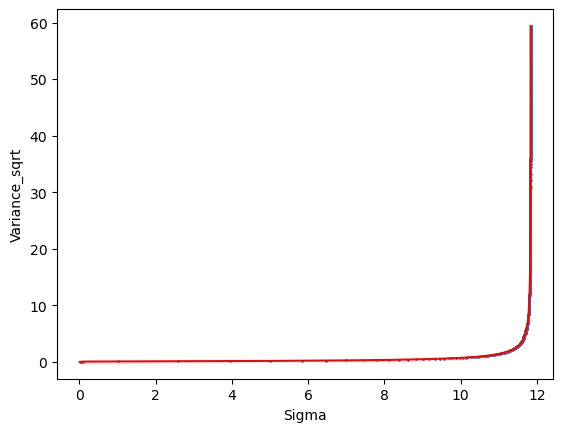

In [17]:
inter_sigma=interpolate.interp1d(Sigmas, Errors, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )
re_sigmas=np.linspace(np.min(Sigmas), np.max(Sigmas), 2*sigma_rsl)
re_var_sqrt=inter_sigma(re_sigmas)
plt.plot(re_var_sqrt, re_sigmas, 'r-', label='interpolated')
plt.scatter(Errors, Sigmas, s=1, label='original')
plt.ylabel('Variance_sqrt')
plt.xlabel('Sigma')

In [19]:
np.savez('./interpolation/StandardD_C0mean.npz', a=Sigmas, b=As, c=C0s, d=Errors)

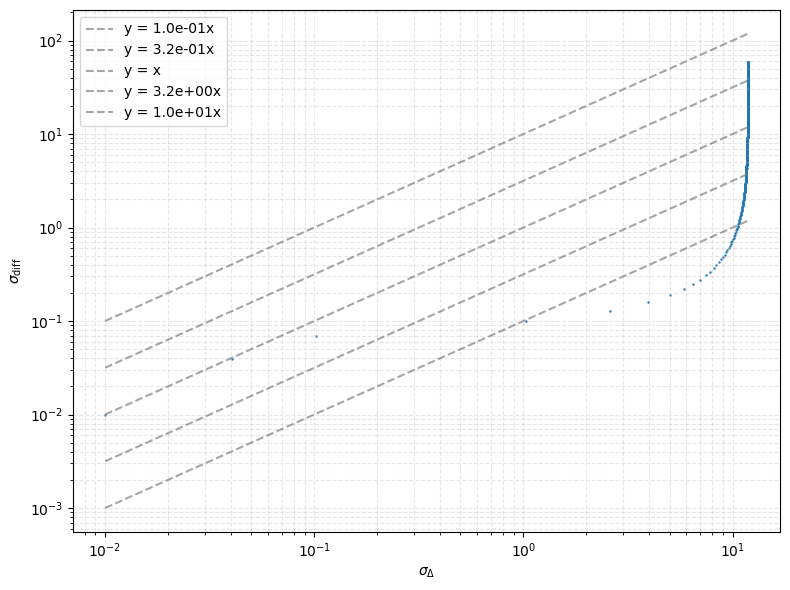

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(Vars_sqrt, sigmas,s=0.5)
plt.ylabel(r'$\sigma_{\rm diff}$')
plt.xlabel(r'$\sigma_\Delta$')
plt.xscale('log')
plt.yscale('log')

x_min = min(Vars_sqrt)
x_max = max(Vars_sqrt)
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)

constants = [-1, -0.5, 0, 0.5, 1]
for c in constants:
    y_ref = x_range * (10**c)  # y = x * 10^c
    plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=f'y = {10**c:.1e}x' if c != 0 else 'y = x')

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()

In [ ]:
# interpolation example

# C0_sigma = interpolate.interp1d(sigmas, C0s, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# A_sigma = interpolate.interp1d(sigmas, As, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# sigma_var = interpolate.interp1d(Vars_sqrt, sigmas, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

In [ ]:
""" np.save('./interpolation/sigmas.npy', sigmas)
np.save('./interpolation/As.npy', As)
np.save('./interpolation/C0s.npy', C0s)
np.save('./interpolation/Vars_sqrt.npy', Vars_sqrt) """